# Unsupervised Classification with K-means

This notebook extracts raster predictor values at Araucaria sample locations, standardizes the predictors using z-scores, and performs K-means clustering with 10 classes.

Workflow:
1. Read Araucaria presence/pseudo-absence points;
2. Read raster predictors;
3. Extract raster values at point locations;
4. Remove incomplete samples;
5. Standardize predictors with z-scores;
6. Run K-means with 10 clusters.

In [41]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [42]:
# ============================================================
# 2. LOAD THE SAMPLE DATA
# ============================================================

# Define the path to the presence and pseudo-absence points.
samples_path = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset/input/"
    "Araucaria_pseudo_absence.gpkg"
)

# Read the point dataset.
samples = gpd.read_file(samples_path)

# Inspect the sample data.
samples.info()
display(samples.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6906 entries, 0 to 6905
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        6906 non-null   int64   
 1   presence  6906 non-null   int64   
 2   geometry  6906 non-null   geometry
dtypes: geometry(1), int64(2)
memory usage: 162.0 KB


,id,presence,geometry
0,1,1,POINT (-49.61149 -28.06746)
1,2,1,POINT (-49.96145 -28.28208)
2,3,1,POINT (-52.27105 -29.39495)
3,4,1,POINT (-48.97911 -25.38728)
4,5,1,POINT (-53.03313 -24.19717)


In [43]:
# ============================================================
# 3. LOAD THE RASTER PREDICTORS
# ============================================================

# Define the directory containing the predictor rasters.
workdir_xvars = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset/input"
)

# List all GeoTIFF files in the predictor directory.
raster_files = sorted(workdir_xvars.glob("*.tif"))

print(f"Number of raster predictors: {len(raster_files)}")

for f in raster_files:
    print(f.name)

# Read raster layer names from file stems.
raster_names = [f.stem for f in raster_files]

raster_names

Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


['HAND',
 'Mean_curvature',
 'NTSI',
 'TPI_11x11',
 'bio1',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'elevation',
 'slope']

In [44]:
# ============================================================
# 4. CHECK COORDINATE REFERENCE SYSTEMS
# ============================================================

# Read the CRS of the first raster.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

# Reproject sample points only if necessary.
if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

print("CRS used for extraction:", samples.crs)

Sample CRS: EPSG:4326
Raster CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
CRS used for extraction: EPSG:4326


ERROR 1: PROJ: internal_proj_identify: /opt/conda/envs/geospatial/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [45]:
# ============================================================
# 5. EXTRACT RASTER VALUES AT SAMPLE LOCATIONS
# ============================================================

# Create a list of point coordinates.
coords = [
    (geom.x, geom.y)
    for geom in samples.geometry
]

# Extract one raster value for each sample point.
for raster_path, raster_name in zip(raster_files, raster_names):

    with rasterio.open(raster_path) as src:

        values = [
            value[0]
            for value in src.sample(coords)
        ]

        # Convert NoData values to NaN.
        if src.nodata is not None:
            values = [
                np.nan if value == src.nodata else value
                for value in values
            ]

        samples[raster_name] = values

# Inspect extracted values.
display(samples.head())

,id,presence,geometry,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,1,1,POINT (-49.61149 -28.06746),543.000000,-0.000022,-0.001883,49.223141,12.920834,16.483334,9.466666,...,9.225000,53.633720,288.463470,21.500000,4.3,17.200001,16.483334,11.200000,1433.0,4.962794
1,2,1,POINT (-49.96145 -28.28208),368.000000,-0.000008,-0.002379,20.628099,13.850000,17.433334,10.333333,...,9.766666,55.178905,292.644684,22.700001,5.0,17.700001,12.100000,12.000000,1319.0,2.667678
2,3,1,POINT (-52.27105 -29.39495),579.000000,0.000051,-0.000750,121.223137,17.104166,21.299999,12.916667,...,9.575000,50.930855,355.210938,26.900000,8.1,18.799999,21.150000,12.916667,610.0,2.404401
3,4,1,POINT (-48.97911 -25.38728),883.000000,-0.000051,-0.001744,-40.528927,17.516666,20.766666,14.233333,...,9.383333,55.853172,271.906860,25.500000,8.7,16.799999,20.766666,14.233333,900.0,6.728432
4,5,1,POINT (-53.03313 -24.19717),184.001007,-0.000002,0.001776,18.719007,20.233334,23.566666,16.400000,...,12.250000,61.250000,295.967865,29.900000,9.9,20.000000,23.566666,17.700001,473.0,1.134165


In [46]:
# ============================================================
# 6. PREPARE THE PREDICTOR MATRIX
# ============================================================

# Keep only raster-derived predictor variables.
X = samples[raster_names].copy()

print("Number of samples:", len(X))
print("Number of predictors:", X.shape[1])

# Check missing values.
missing_values = X.isna().sum()

display(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

# Keep only samples with complete predictor information.
valid_samples = X.notna().all(axis=1)

X = X.loc[valid_samples].copy()
samples_complete = samples.loc[valid_samples].copy()

print("Samples before removing NA:", len(samples))
print("Complete samples:", len(X))

# Inspect predictor statistics.
display(X.describe().T)

Number of samples: 6906
Number of predictors: 25


HAND              69
slope             20
NTSI              16
TPI_11x11          6
Mean_curvature     6
bio10              6
bio11              6
bio12              6
bio1               6
bio13              6
bio14              6
bio16              6
bio15              6
bio18              6
bio19              6
bio2               6
bio17              6
bio3               6
bio4               6
bio6               6
bio5               6
bio7               6
bio8               6
bio9               6
elevation          6
dtype: int64

Samples before removing NA: 6906
Complete samples: 6827


,count,mean,std,min,25%,50%,75%,max
HAND,6827.0,157.748688,231.813187,0.000000,29.002000,6.700000e+01,184.000000,2191.000000
Mean_curvature,6827.0,-0.000002,0.000031,-0.000202,-0.000011,-5.173617e-07,0.000009,0.000323
NTSI,6827.0,-0.000033,0.004033,-0.065695,-0.001802,-3.986121e-04,0.001711,0.044770
TPI_11x11,6827.0,4.083263,62.508156,-320.082642,-15.801653,-9.917355e-02,16.417356,727.702454
bio1,6827.0,20.623955,4.385602,9.383333,17.068750,1.945000e+01,25.222917,27.791666
bio10,6827.0,22.965624,3.228075,12.066667,20.533333,2.276667e+01,26.058332,28.733334
bio11,6827.0,18.083557,5.640602,6.466667,13.366667,1.598333e+01,24.299999,27.266666
bio12,6827.0,1718.132812,445.048157,404.000000,1505.500000,1.667000e+03,1935.000000,3782.000000
bio13,6827.0,244.929688,70.826691,59.000000,189.000000,2.310000e+02,304.000000,569.000000
bio14,6827.0,62.341438,45.865475,0.000000,20.000000,6.100000e+01,100.000000,236.000000


In [47]:
# ============================================================
# 7. STANDARDIZE PREDICTORS USING Z-SCORE
# ============================================================

# K-means uses Euclidean distance and is sensitive to
# differences in variable scales. Standardize each predictor
# to mean = 0 and standard deviation = 1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the standardized matrix back to a DataFrame.
X_scaled = pd.DataFrame(
    X_scaled,
    columns=raster_names,
    index=X.index
)

display(X_scaled.head())

# Check standardized statistics.
display(
    X_scaled.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,bio14,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,1.662026,-0.650209,-0.458867,0.722197,-1.756586,-2.008244,-1.527767,0.044644,-0.846208,1.082780,...,-1.088018,-1.067652,0.748832,-2.051263,-1.287089,0.033163,-1.365982,-1.447834,1.852365,1.650655
1,0.907052,-0.186365,-0.581713,0.264702,-1.544702,-1.713930,-1.374107,-0.173326,-1.142728,0.951953,...,-0.714696,-0.919314,0.785404,-1.715990,-1.166145,0.187240,-2.489938,-1.300658,1.590023,0.538399
2,1.817335,1.669027,-0.177943,1.874131,-0.802637,-0.516018,-0.916085,-0.649714,-0.888568,0.101578,...,-0.846795,-1.327127,1.332650,-0.542534,-0.630537,0.526210,-0.169374,-1.132019,-0.041558,0.410810
3,3.128832,-1.549480,-0.424268,-0.713754,-0.708572,-0.681247,-0.682641,0.294073,-0.069607,0.537667,...,-0.978893,-0.854584,0.604017,-0.933686,-0.526871,-0.090100,-0.267667,-0.889792,0.625803,2.506316
4,0.113256,-0.014623,0.448492,0.234159,-0.089076,0.186206,-0.298493,-0.368825,-0.662647,0.232405,...,0.996839,-0.336488,0.814471,0.295650,-0.319539,0.895996,0.450298,-0.252029,-0.356828,-0.204770


,mean,std,min,max
HAND,-3.330506e-17,1.000073,-0.680549,8.771720
Mean_curvature,-8.326266e-18,1.000073,-6.370003,10.330237
NTSI,0.000000e+00,1.000073,-16.282876,11.110070
TPI_11x11,-8.326266e-18,1.000073,-5.186358,11.577244
bio1,-3.996608e-16,1.000073,-2.563261,1.634493
bio10,1.332203e-16,1.000073,-3.376549,1.786865
bio11,1.332203e-16,1.000073,-2.059664,1.628156
bio12,-4.163133e-17,1.000073,-2.953004,4.637741
bio13,9.991519e-17,1.000073,-2.625328,4.575875
bio14,-3.330506e-17,1.000073,-1.359323,3.786536


In [48]:
# ============================================================
# 8. K-MEANS CLUSTERING
# ============================================================

# Define the number of environmental clusters.
n_clusters = 10

# Fit K-means using the standardized predictors.
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=123,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the sample dataset.
samples_complete["cluster"] = cluster_labels + 1

# Inspect the number of samples per cluster.
cluster_counts = (
    samples_complete["cluster"]
    .value_counts()
    .sort_index()
)

print("Number of samples per cluster:")
display(cluster_counts)

# Inspect the resulting dataset.
display(
    samples_complete[
        ["cluster"] + raster_names
    ].head()
)

Number of samples per cluster:


cluster
1      879
2      665
3     1177
4      848
5      124
6      367
7      476
8      760
9      539
10     992
Name: count, dtype: int64

,cluster,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,1,543.000000,-0.000022,-0.001883,49.223141,12.920834,16.483334,9.466666,1738.0,185.0,...,9.225000,53.633720,288.463470,21.500000,4.3,17.200001,16.483334,11.200000,1433.0,4.962794
1,1,368.000000,-0.000008,-0.002379,20.628099,13.850000,17.433334,10.333333,1641.0,164.0,...,9.766666,55.178905,292.644684,22.700001,5.0,17.700001,12.100000,12.000000,1319.0,2.667678
2,3,579.000000,0.000051,-0.000750,121.223137,17.104166,21.299999,12.916667,1429.0,182.0,...,9.575000,50.930855,355.210938,26.900000,8.1,18.799999,21.150000,12.916667,610.0,2.404401
3,6,883.000000,-0.000051,-0.001744,-40.528927,17.516666,20.766666,14.233333,1849.0,240.0,...,9.383333,55.853172,271.906860,25.500000,8.7,16.799999,20.766666,14.233333,900.0,6.728432
4,10,184.001007,-0.000002,0.001776,18.719007,20.233334,23.566666,16.400000,1554.0,198.0,...,12.250000,61.250000,295.967865,29.900000,9.9,20.000000,23.566666,17.700001,473.0,1.134165


In [49]:
# ============================================================
# 9. INSPECT K-MEANS CENTROIDS
# ============================================================

# Cluster centers are expressed in standardized z-score units.
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=raster_names,
    index=[
        f"Cluster {i}"
        for i in range(1, n_clusters + 1)
    ]
)

display(cluster_centers)

,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,bio14,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
Cluster 1,0.850505,-0.030460,-0.539400,0.314708,-1.242450,-1.268625,-1.158777,0.118052,-0.843702,1.113589,...,-0.749039,-1.010710,0.863212,-1.325918,-0.961997,0.253358,-1.344453,-0.970890,0.928978,0.636238
Cluster 2,-0.206898,0.072120,0.227537,-0.079403,0.292320,0.266779,0.189550,-0.732962,0.088919,-0.945661,...,0.876539,0.131747,-0.039582,0.267080,-0.039563,0.365136,0.450227,0.041294,-0.024999,-0.059716
Cluster 3,-0.308655,-0.053130,-0.117101,-0.162283,-0.619186,-0.543309,-0.645032,-0.384490,-0.461440,0.182645,...,-0.314400,-0.708830,0.678054,-0.671240,-0.578117,0.290761,-0.170619,-0.819794,0.447471,-0.201853
Cluster 4,-0.476766,0.030856,0.358985,-0.068442,1.237814,1.166908,1.311684,0.848161,1.320730,-0.490229,...,-0.778192,1.245751,-1.322755,1.081611,1.451768,-1.396341,0.966723,1.351181,-1.057673,-0.403052
Cluster 5,4.430835,2.228429,-0.761854,4.377359,-1.818368,-2.298270,-1.528624,0.684998,1.379060,-0.533742,...,0.675440,-0.623057,0.418361,-1.928239,-1.745922,0.987200,-1.635012,-1.747947,3.054652,2.921859
Cluster 6,1.142673,-1.224979,-0.417108,-0.946792,-0.968426,-1.139145,-0.894249,-0.163615,0.655669,-0.693365,...,0.512734,-0.592449,0.475231,-0.993752,-1.084229,0.837724,-0.681088,-1.101967,1.441007,1.639250
Cluster 7,-0.538066,0.049999,0.544376,-0.067155,1.260933,1.121652,1.341579,2.026875,1.156608,1.295328,...,-1.105779,1.897665,-1.429412,0.791281,1.559516,-1.908731,1.074154,1.299018,-1.163278,-0.532505
Cluster 8,-0.498955,0.045705,0.461312,-0.092451,1.034583,0.926633,1.055928,0.220128,0.762395,-1.090497,...,0.903698,0.619248,-1.057455,1.191182,0.738536,-0.003410,0.925370,0.938619,-0.818193,-0.476773
Cluster 9,-0.299825,0.068132,0.512683,-0.086863,0.843594,0.849662,0.811890,-1.893476,-1.082240,-1.147427,...,0.373323,0.643080,-0.662915,0.921877,0.776487,-0.368125,0.742813,0.787190,-0.458070,-0.213535
Cluster 10,-0.014392,0.093919,-0.486168,-0.021222,-0.688970,-0.408684,-0.828183,-0.019601,-0.859530,1.010157,...,0.475660,-0.853983,1.216003,-0.316849,-0.792829,1.064580,-0.906092,-0.493713,0.085793,-0.174569


In [50]:
# ============================================================
# 10. CHECK FEATURE ORDER BEFORE RASTER PREDICTION
# ============================================================

# Use exactly the same predictor order used during model fitting.
model_features = list(
    scaler.feature_names_in_
)

# Create a dictionary linking raster names to file paths.
raster_dict = {
    path.stem: path
    for path in raster_files
}

# Check whether all predictors used in the model are available.
missing_rasters = [
    name
    for name in model_features
    if name not in raster_dict
]

if missing_rasters:
    raise ValueError(
        "Missing raster predictors: "
        + ", ".join(missing_rasters)
    )

# Reorder raster files to match the model feature order.
raster_files = [
    raster_dict[name]
    for name in model_features
]

raster_names = model_features

print("Predictor order checked successfully.")
print(raster_names)

Predictor order checked successfully.
['HAND', 'Mean_curvature', 'NTSI', 'TPI_11x11', 'bio1', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'elevation', 'slope']


In [51]:
# ============================================================
# 11. MAP K-MEANS CLUSTERS TO THE RASTER GRID
# ============================================================

from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling


# Define output directory.
output_dir = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/"
    "dataset/output"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_raster = (
    output_dir /
    "Araucaria_KMeans_10classes.tif"
)


# ------------------------------------------------------------
# Use the first raster as the reference grid.
# ------------------------------------------------------------

with rasterio.open(raster_files[0]) as ref:

    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

    profile = ref.profile.copy()

    profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="deflate",
        tiled=True
    )


    # --------------------------------------------------------
    # Open predictor rasters.
    # --------------------------------------------------------

    original_sources = [
        rasterio.open(path)
        for path in raster_files
    ]

    aligned_sources = []


    try:

        # ----------------------------------------------------
        # Align all predictors to the reference grid.
        # ----------------------------------------------------

        for src in original_sources:

            vrt = WarpedVRT(
                src,
                crs=ref_crs,
                transform=ref_transform,
                width=ref_width,
                height=ref_height,
                resampling=Resampling.bilinear
            )

            aligned_sources.append(vrt)


        # ----------------------------------------------------
        # Create output raster.
        # ----------------------------------------------------

        with rasterio.open(
            output_raster,
            "w",
            **profile
        ) as dst:


            # Process one raster block at a time.
            for _, window in ref.block_windows(1):

                predictor_blocks = []
                valid_mask = None


                # ---------------------------------------------
                # Read predictors for the current block.
                # ---------------------------------------------

                for src in aligned_sources:

                    block = src.read(
                        1,
                        window=window,
                        masked=True
                    )

                    current_valid = (
                        ~np.ma.getmaskarray(block)
                    )

                    if valid_mask is None:
                        valid_mask = current_valid.copy()
                    else:
                        valid_mask &= current_valid


                    # Convert to float before inserting NaN.
                    block_float = (
                        block
                        .astype("float32")
                        .filled(np.nan)
                    )

                    predictor_blocks.append(
                        block_float
                    )


                # ---------------------------------------------
                # Create empty output block.
                # ---------------------------------------------

                cluster_block = np.zeros(
                    (
                        window.height,
                        window.width
                    ),
                    dtype=np.uint8
                )


                # ---------------------------------------------
                # Classify valid pixels.
                # ---------------------------------------------

                if (
                    valid_mask is not None
                    and np.any(valid_mask)
                ):

                    pixel_data = np.column_stack(
                        [
                            layer[valid_mask]
                            for layer in predictor_blocks
                        ]
                    )


                    # Keep only finite values.
                    finite_mask = np.all(
                        np.isfinite(pixel_data),
                        axis=1
                    )


                    if np.any(finite_mask):

                        pixel_data_valid = pixel_data[
                            finite_mask
                        ]


                        # -------------------------------------
                        # Preserve feature names.
                        # -------------------------------------

                        pixel_df = pd.DataFrame(
                            pixel_data_valid,
                            columns=raster_names
                        )


                        # -------------------------------------
                        # Apply the same z-score scaling.
                        # -------------------------------------

                        pixel_scaled = scaler.transform(
                            pixel_df
                        )

                        pixel_scaled_df = pd.DataFrame(
                            pixel_scaled,
                            columns=raster_names
                        )


                        # -------------------------------------
                        # Match K-means dtype.
                        # -------------------------------------

                        kmeans_dtype = (
                            kmeans
                            .cluster_centers_
                            .dtype
                        )

                        pixel_scaled_df = (
                            pixel_scaled_df.astype(
                                kmeans_dtype
                            )
                        )


                        # -------------------------------------
                        # Predict cluster.
                        # -------------------------------------

                        pixel_clusters = (
                            kmeans.predict(
                                pixel_scaled_df
                            )
                            + 1
                        )


                        # -------------------------------------
                        # Return classes to raster positions.
                        # -------------------------------------

                        rows, cols = np.where(
                            valid_mask
                        )

                        rows = rows[
                            finite_mask
                        ]

                        cols = cols[
                            finite_mask
                        ]


                        cluster_block[
                            rows,
                            cols
                        ] = pixel_clusters.astype(
                            np.uint8
                        )


                # Write block to disk.
                dst.write(
                    cluster_block,
                    1,
                    window=window
                )


    finally:

        for src in aligned_sources:
            src.close()

        for src in original_sources:
            src.close()


print("K-means raster created successfully:")
print(output_raster)

K-means raster created successfully:
/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/output/Araucaria_KMeans_10classes.tif


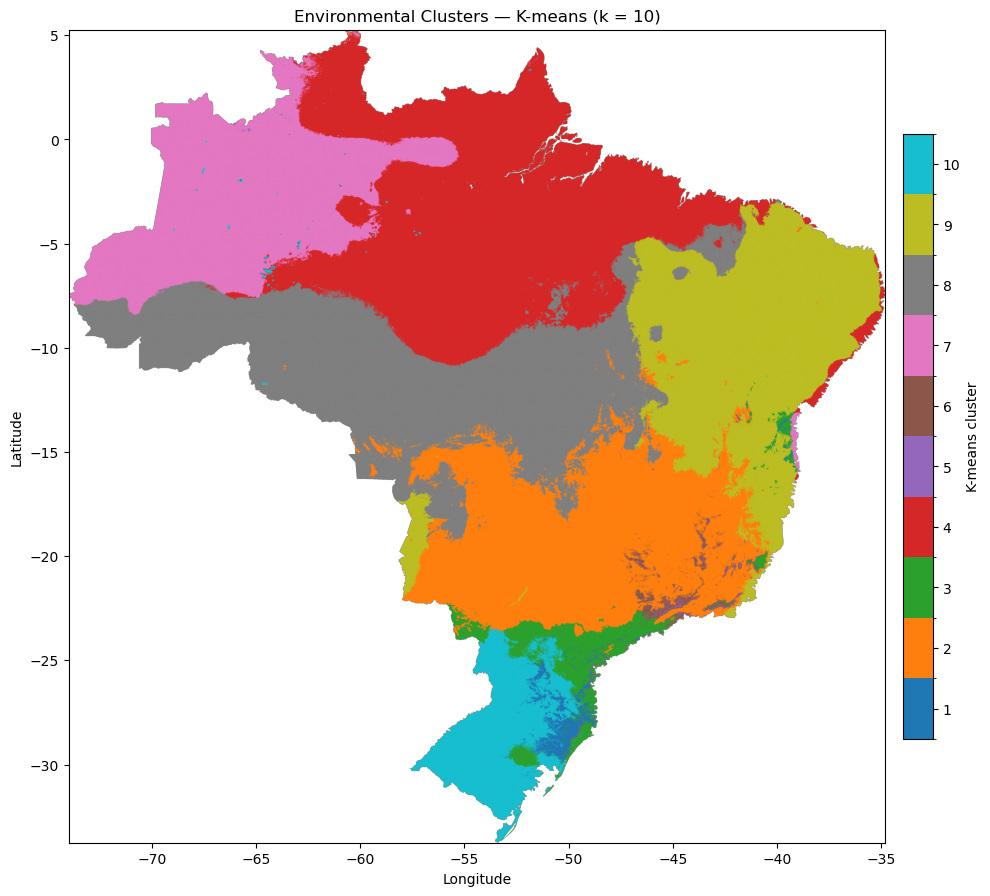

In [52]:
# ============================================================
# 13. PLOT K-MEANS RASTER
# ============================================================

import matplotlib.pyplot as plt
import rasterio
from matplotlib.colors import ListedColormap, BoundaryNorm


# Read the classified raster.
with rasterio.open(output_raster) as src:

    data = src.read(1)

    # Convert NoData to NaN for plotting.
    data = data.astype("float32")
    data[data == src.nodata] = np.nan

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]


# Create a discrete colormap with 10 classes.
cmap = plt.get_cmap(
    "tab10",
    10
)

# Define class boundaries.
bounds = np.arange(
    0.5,
    11.5,
    1
)

norm = BoundaryNorm(
    bounds,
    cmap.N
)


# Plot.
fig, ax = plt.subplots(
    figsize=(10, 10)
)

im = ax.imshow(
    data,
    cmap=cmap,
    norm=norm,
    extent=extent,
    origin="upper"
)

# Add colorbar.
cbar = plt.colorbar(
    im,
    ax=ax,
    ticks=np.arange(1, 11),
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "K-means cluster"
)

ax.set_title(
    "Environmental Clusters — K-means (k = 10)"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# 14. PRESENCE AND PSEUDO-ABSENCE BY K-MEANS CLUSTER
# ============================================================

# Count presence and pseudo-absence points in each cluster.
cluster_table = pd.crosstab(
    samples_complete["cluster"],
    samples_complete["presence"]
)

# Rename columns for clarity.
cluster_table = cluster_table.rename(
    columns={
        0: "Pseudo-absence",
        1: "Presence"
    }
)

# Add total number of points per cluster.
cluster_table["Total"] = cluster_table.sum(axis=1)

display(cluster_table)

presence,Pseudo-absence,Presence,Total
cluster,,,
1,11,868,879
2,565,100,665
3,79,1098,1177
4,847,1,848
5,2,122,124
6,13,354,367
7,476,0,476
8,760,0,760
9,537,2,539


Presence and pseudo-absence samples occupy largely distinct regions of the feature space. Several environmental clusters are almost exclusively associated with one class, indicating strong environmental separability but limited overlap between presence and pseudo-absence conditions.

High class separability may reflect a true ecological signal, but it can also result from pseudo-absence sampling that is too environmentally distant from known occurrences.
